In [1]:
from shapely.geometry import shape
import json
import pandas as pd
import pandas as pd
import matplotlib.colors as mcolors
import statsmodels.api as sm
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt

In [3]:
# PID_df=pd.read_csv('data/lookup/PID_location_all.csv')
# csc_df= pd.read_csv('data/WSCI/PID_location_WSCI.csv')
npp_df=pd.read_csv('data/processed/PID_npp.csv')



In [4]:
npp_df.rename(columns={'NPP_kgC_m2_yr': "Npp"}, inplace=True)

grouped = npp_df.groupby('PID').apply(lambda x: x.sort_values('year')['Npp'].to_numpy())
grouped = grouped[grouped.apply(lambda x: ~np.isnan(x).any())]

In [5]:
def compute_volatility(arr): 
    '''
    Log of inverse CoV

    '''
    s=arr.mean()
    sd=arr.std()
    arr= pd.Series((arr))
    
    v= (s/arr.std())
    return v , s, sd

In [6]:
volatility=[]
PID_list=[]
mean=[]
sad=[]
for pid, arr in grouped.items():
    if arr.shape[0] > 5:
        if (arr == 0).sum() < 4: 
            v , s, sd = compute_volatility(arr)
            # returns = np.diff(arr) / arr[:-1]

            # returns = np.abs(returns)
            # v = np.std(returns, ddof=1)
            volatility.append(v)
            PID_list.append(pid)
            mean.append(s)
            sad.append(sd)

npp_df1 = pd.DataFrame({'PID': PID_list, 'transformed npp': volatility, 'mean': mean, 'sd': sad })

In [7]:
npp_df1.to_csv('data/processed/PID_npp_full.csv', index=False)

Text(0, 0.5, 'Std NPP')

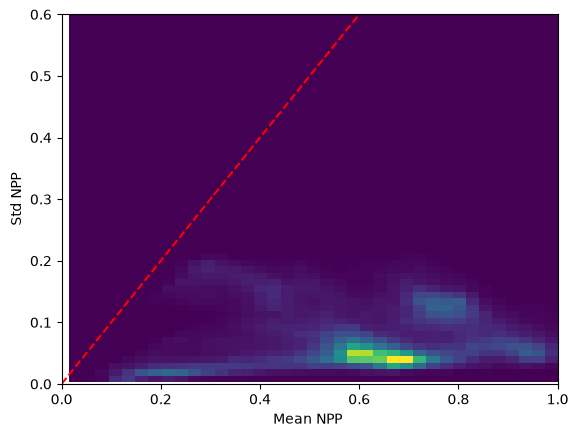

In [31]:
plt.hist2d(npp_df1['mean'], npp_df1['sd'], bins=90, cmap='viridis')

x = np.linspace(0, 1, 100)

# 1-1 line
y = x

plt.plot(x, y, linestyle='--', label='1:1 line', color='red')

plt.xlim(0., 1)
plt.ylim(0.,0.6)
plt.xlabel('Mean NPP ')
plt.ylabel('Std NPP')

In [33]:
df=npp_df1.merge(PID_df, on='PID', how='left')

In [41]:
fd_df=pd.read_csv('data/final/final_dataset_with_aridity.csv')

In [43]:
biome_mapping = {
    'Temperate broadleaf forests': 'Temperate broadleaf forests',
    'Temperate conifer forests': 'Temperate conifer forests',
    'Temperate grasslands': 'Temperate grasslands',
    'Xeric shrublands': 'Xeric shrublands',
    'Mediterranean woodlands': 'Mediterranean woodlands',
    'Flooded grasslands': 'Flooded grasslands',
    'Mangroves': 'Mangroves',
    'Tundra': 'Boreal and Tundra forests',
    'Boreal forests or taiga': 'Boreal and Tundra forests',
    'Tropical grasslands': 'Tropical',
    'Tropical coniferous forests': 'Tropical',
    'Tropical moist broadleaf forests': 'Tropical',
    'Tropical dry broadleaf forests': 'Tropical',
    np.nan: np.nan,  # Will be dropped
}
# Create a new column with readable biome names
fd_df['biome'] = fd_df['biome'].map(biome_mapping)

In [64]:
fd_df.drop(
    fd_df[fd_df["biome"].isin(["Mangroves", "Flooded grasslands"])].index,
    inplace=True
)

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def ridgeline_plot(df, biome_colors, bandwidth=0.2, spacing=1.2):
    """
    Ridgeline plot of transformed NPP by biome.
    """

    biomes = (df["biome"].unique())

    # KDE grid
    x_min = df["transformed npp"].min()
    x_max = df["transformed npp"].max()
    x_grid = np.linspace(x_min, x_max, 300)

    fig, ax = plt.subplots(figsize=(15, 0.9 * len(biomes) + 2))

    # give extra left margin for labels
    plt.subplots_adjust(left=0.2)

    for i, biome in enumerate(biomes):

        subset = df.loc[df["biome"] == biome, "transformed npp"].dropna().values

        if len(subset) < 2:
            continue

        kde = gaussian_kde(subset, bw_method=bandwidth)
        y = kde(x_grid)

        y_offset = i * spacing
        color = biome_colors.get(biome, "gray")

        # ridge
        ax.fill_between(
            x_grid,
            y_offset,
            y + y_offset,
            color=color,
            alpha=0.6
        )
        ax.plot(x_grid, y + y_offset, color=color, linewidth=1)

        # 🧠 biome label OUTSIDE plot (left side)
        ax.text(
            x_min - 0.05 * (x_max - x_min),  # push left outside axis
            y_offset,
            biome,
            va="center",
            ha="right",
            fontsize=9,
            clip_on=False
        )

    # styling
    ax.set_yticks([])
    ax.set_xlabel(" Ecosystem Stability")
    ax.set_title("Ridgeline Plot of Ecosystem Stability by Biome")

    ax.set_xlim(x_min, x_max)

    plt.tight_layout()
    plt.show()

In [83]:
# Color map for ecoregions
biome_colors =  {
    'Temperate broadleaf forests': '#3CB371',      # Medium Sea Green
    'Temperate conifer forests': '#228B22',        # Forest Green
    'Temperate grasslands': '#DAA520',             # Goldenrod
    'Xeric shrublands': '#CD853F',                 # Peru - desert brown
    'Boreal and Tundra forests': '#4682B4',        # Steel Blue
    'Mediterranean woodlands': '#8FBC8F',          # Dark Sea Green
    'Tropical': '#00FF00',                         # Lime Green
}

In [86]:
df=pd.read_csv('data/final/final_dataset_with_aridity1.csv')

In [87]:
df.drop(
    df[df["biome"].isin(["Mangroves", "Flooded grasslands"])].index,
    inplace=True
)

In [88]:
df['biome'] = df['biome'].map(biome_mapping)

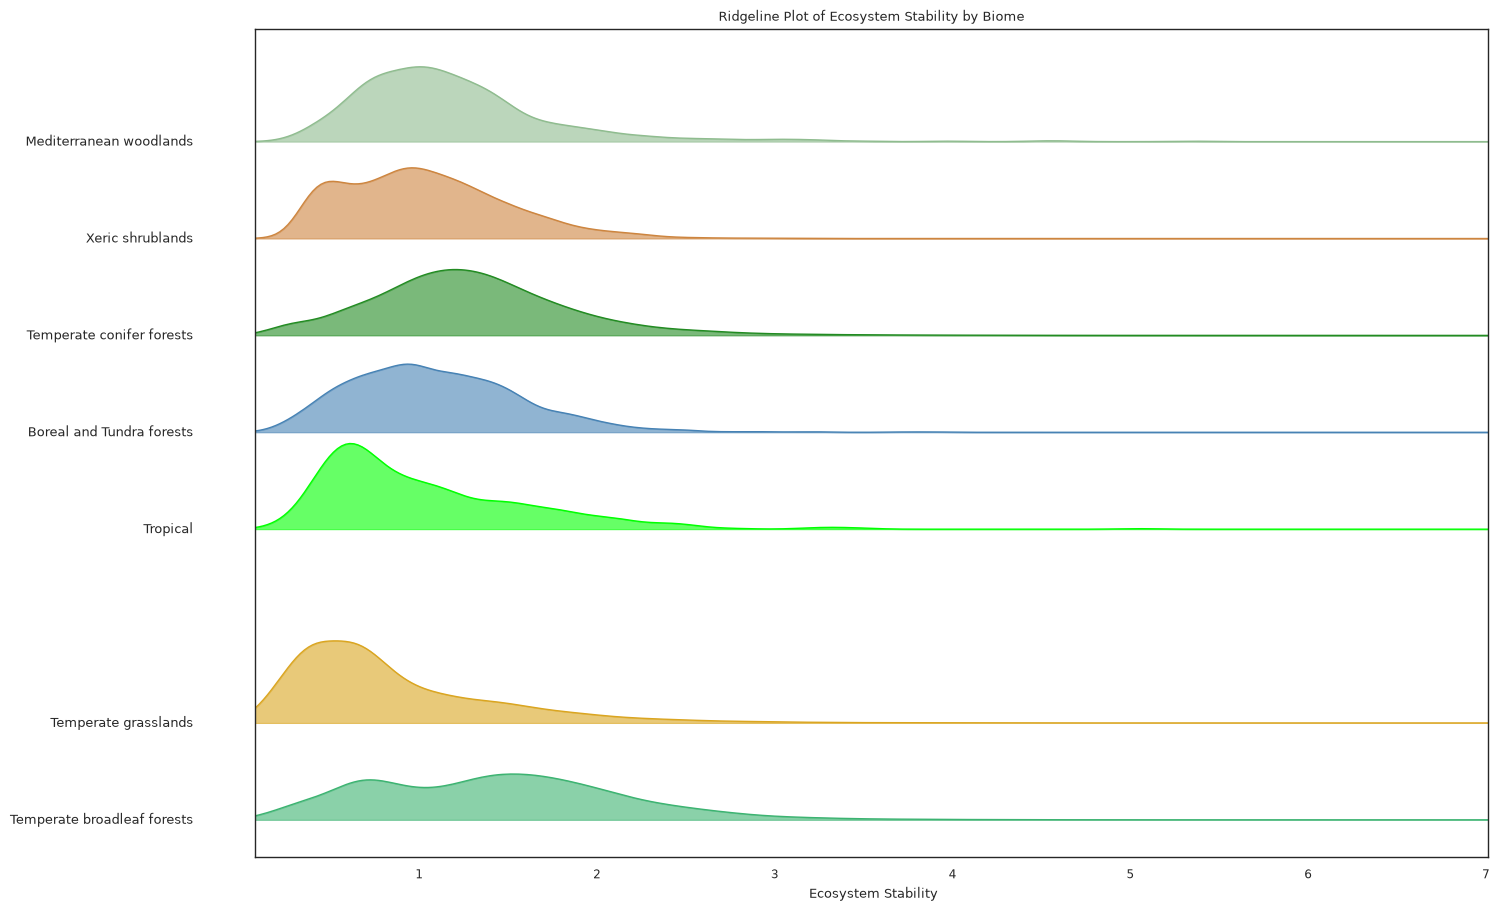

In [89]:
ridgeline_plot(df, biome_colors)